poem
{
    'topic': '猫咪',
    'poem': '## 
《晨起闻猫语》\n\n金阳初照眼，暖腹自和匀。\n鬣尾垂微动，花丛蘸露新。\n缘柱频登陟，摩天欲寄身。\n扑蝶疾如剑，低眉暗
嗅尘。\n近前悄作语，何事谶如神？',
    'ci_poem': '## 
《养猫考》\n\n它把夜晚分成三段：\n先是巡视纸箱王国的疆域，\n然后舔净瓷碗，\n最后蜷成句号。\n\n办公室里有它的卧榻，\
n键盘卧着算它温柔。\n毛线球背叛了毛线团，\n纸盒正酝酿新的秤砣。\n\n当它突然静止，\n比椅子稳固，\n灰尘在光里缓慢，\n
时光突然显出材质。',
    'content_type': '诗'
}

joke
{
    'topic': '猫咪',
    'ci_poem': '## 
《九夜书》\n\n猫有九夜，盈月时蜷进纸箱，残月时数梧桐落叶。\n——题记\n\n一\n薄暮的光斜过屋瓦，\n虎斑的瞳仁半阖，\n它
们卧成不规则的岛，\n前爪压住风尾。\n\n二\n绒毛有云的质地，\n鼻尖沁着奶香的星群。\n它们回避过于清晰的事物，\n像银杏
叶习惯在秋天变轻。\n\n三\n有时踱步如落棋，\n在影子里埋下纺车般的响。\n窗台上的茉莉，\n正拆解某个完整的谜语。\n\n四\
n午后的纱帘铺开宣纸，\n脊背是连绵的丘陵。\n当夜色浸透毛尖，\n屏风突然长出绒毛的月亮。\n\n五\n它们豢养着瓷器的睡眠，
\n碰落杯沿的露水微微颤动。\n一枚毛线球滚过地板，\n拆散我整个雨季的迂回。\n\n六\n古寺的铜钟悬而未响，\n腕间的表盘突
然失重。\n若要为柔软界定疆域，\n就让尾巴摆成无解的波浪。\n\n七\n当镇的酒碗底游过锦鲤，\n某根琴弦开始返潮。\n它们能
听见瓷器内部，\n春天融化的声响。\n\n八\n有人用鳗鱼祭拜闪电，\n有人将月亮种进陶罐。\n而猫爪按住残缺的印，\n仿佛按住
成住坏空。\n\n九\n直到白昼的银簪划破窗纸，\n它们化作团蒲上蜷曲的云团。\n呵，九夜不过是原乡的倒影，\n——在苏醒前已练
习千次消隐。',
    'joke': '# 
猫咪主题笑话\n\n**笑话一：**\n\n有个人养了一只猫，他问猫：“你为什么总是这么高冷？”\n\n猫看了他一眼，说：“因为我怕我
一热情，你就会以为我是狗。”\n\n**笑话二：**\n\n一只猫走进咖啡馆，点了一杯拿铁。\n\n服务员问：“要不要加糖？”\n\n猫说
：“不用了，我已经够甜了。”\n\n服务员又问：“那要不要加奶？”\n\n猫叹了口气说：“我都已经是猫了，你还想加什么奶？”\n\n*
*笑话三：**\n\n一只猫对主人说：“我今天看到一个老鼠，它居然不怕我。”\n\n主人问：“那你怎么做的？”\n\n猫说：“我当然不
能丢猫的脸，所以我也假装没看见它。”\n\n**笑话四：**\n\n猫和狗聊天。\n\n狗说：“我主人对我真好，每天带我散步，给我好
吃的。”\n\n猫淡淡地说：“那是因为你太好骗了。我主人以为他养了我，其实是我在养他。”\n\n希望这些猫咪笑话能让你会心一笑
！🐱',
    'content_type': '笑话'
}

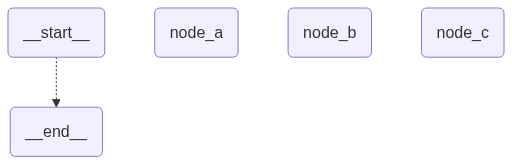

In [2]:
# add_conditional_edges
from typing import TypedDict, Literal, Sequence

from aiohttp.web_fileresponse import content_type
from langchain_classic.evaluation.parsing import json_schema
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from rich import print as rprint

load_dotenv(override=True)

model = ChatOpenAI(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": { "type": "disabled" }
    }
)
class OverALlState(TypedDict):
    topic: str
    poem: str
    ci_poem: str
    joke: str
    content_type: str

def node_a(state: OverALlState) -> dict:
    poem = model.invoke([f"写一首关于{state['topic']}的诗"]).content
    return {
        "poem": poem
    }

def node_c(state: OverALlState) -> dict:
    ci_poem = model.invoke([f"写一首关于{state['topic']}的诗"]).content
    return {
        "ci_poem": ci_poem
    }

def node_b(state: OverALlState) -> dict:
    joke = model.invoke([f"写一个关于{state['topic']}主题的笑话"]).content
    return {
        "joke": joke
    }

def route(state: OverALlState) -> Sequence[Literal["node_a", "node_b", "node_c"]]:
    if "诗" in state["content_type"]:
        return ["node_a","node_c"]
    else:
        return ["node_b","node_c"]

builder = StateGraph(state_schema=OverALlState)

builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_conditional_edges(START, route)
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
builder.add_edge("node_c", END)

graph = builder.compile()

poem = graph.invoke({"topic": "猫咪", "content_type": "诗"})

joke = graph.invoke({"topic": "猫咪", "content_type": "笑话"})

rprint("poem", poem)
rprint("joke", joke)

from IPython.display import display
display(graph)




